# Model Evaluation Metrics for Regression and Classification

### Model Evaluation for Regression
##### Mean Squared Error (MSE)
  - Measures the average squared difference betwen predicted and actual values
  - Sensitive to outliers due to squaring of errors
##### Mean Absolute Error (MAE)
  - Measures the average absolute difference between predicted and actual values
  - Provides a more interpretable measures but less sensitive to outliers
##### Root mean Square Erroe (RMSE)
  - Square root of MSE, providing errors in the same units as the target variable
---
### Model Evaluation for Classification
##### Accuracy
  - Proportion of crrectly predicted instances
  - Useful when the dataset is balanced
  - = (TP+TN)/(TP+TN+FN+FP)
  - But what if dataset is imblanced like 900:100 for 0 and 1, then if result is 0 only it will show 90% accuracy
  
##### Precision (Imblanced dataset)
   - `TP/(TP+FP)`
   - OF all the predicted result how many of them are correctly predicted
   - Fraction of positive that are correct
   - Goal is to keep true positive & and negative more then false once
   - Important for applications like fraud detection, where false positives are costly

##### Recall (Sensitivity)
   - `TP/(TP+FN)`
   - Fraction of Positive prediction that are correct
   - Useful in cases where missing positives instances is critical
  
##### F1 Score
   - Harmonic mean of precision and recall
   - Balances precision and recall, especially useful for imbalanced dataset

---

# Introduction to Cross-Validation

It is a robust model evaluation technique that provides more reliable estimate of model performance by spilliting the dataset into multiple training and testing subsets

### Key Cross-Validation Techniques 
##### K-Fold Cross Validation
  - Splits the dataset into K equal parts
  - Trains the model on K-1 folds and tests on the remaining fold, repeating the process K times
  - The Average of the K test Scores provides the final evaluation metric
  
##### Stratified K-Fold
  - Ensures each fold has a porportional representatio of classes in classificatio problems

##### Leave-One-Out Cross-Validation(LOOCV)
  - Trains the model on n-1 samples and test on the remaining one. Repeated for all samples
  - Computationally expensice for large datasets

### Advantages
- Reduces the Risk of voerfitting by testing on multiple subsets of data
- Provides a more generalized evaluation of model performance


---


# Understanding the Confusion Matrix
The confusion matrix is a table that summarizes the performance of a classification model by comparing predicted and actual values

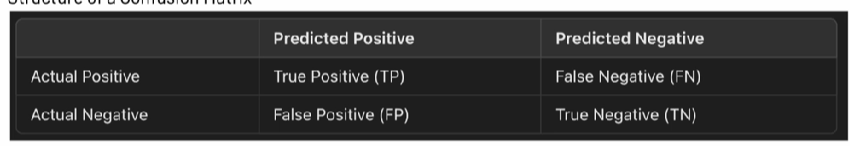

Key Metrics Derived
   - True Positive Rate (TPR)
     - Small as recall
   - False Positive Rate (FPR)
     - Proportion of negatives incorrectly classified as positives
   - Specificity
     - Proportion of negatives correctly classified

---


# Hands-on
- Evaluate a model using cross-validation to obtain a more accurate estimate of classification model preformance

In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load Dataset
data = load_iris()
X,y = data.data, data.target

In [6]:
# Initialize Classifier
model = RandomForestClassifier(random_state=42)

In [7]:
# Perform K-fold Cross-validation
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

In [8]:
# Outputs Results
print("Cross-Validation Scores", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-Validation Scores [1.         0.96666667 0.93333333 0.93333333 0.96666667]
Mean Accuracy: 0.9600000000000002


---


### Generate and Interpret a confusion matrix for a classification model

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

In [10]:
#Loading the dataset

data = load_iris()
X,y = data.data, data.target

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 42)

In [12]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(X_test)

In [18]:
cm = confusion_matrix(y_test, y_pred)

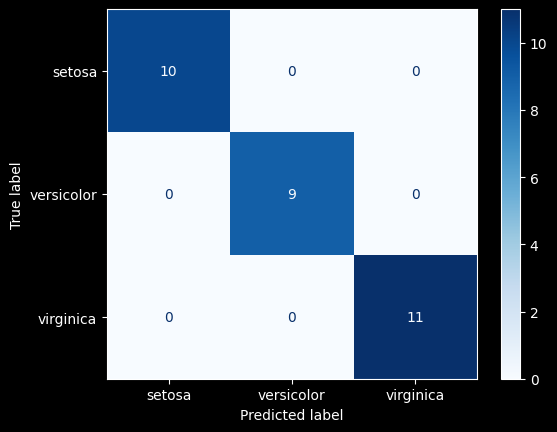

In [22]:
#Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap = "Blues")
plt.show()

In [23]:
print("\nClassification Report\n", classification_report(y_test, y_pred))


Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

